In [1]:
import numpy as np
import pandas as pd

from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [2]:
data = pd.DataFrame({
    "CGPA": [6.5, 6.7, 7.0, 7.5, 8.0],
    "Attendance": [70, 75, 80, 85, 90],
    "Projects": [1, 2, 2, 4, 5],
    "Package": [4.20, 5.10, 6.30, 7.80, 9.20]
})

data

,CGPA,Attendance,Projects,Package
0,6.5,70,1,4.2
1,6.7,75,2,5.1
2,7.0,80,2,6.3
3,7.5,85,4,7.8
4,8.0,90,5,9.2


In [3]:
X = data[["CGPA", "Attendance", "Projects"]]
y = data["Package"]

print("Features:")
print(X)

print("\nTarget:")
print(y)

Features:
   CGPA  Attendance  Projects
0   6.5          70         1
1   6.7          75         2
2   7.0          80         2
3   7.5          85         4
4   8.0          90         5

Target:
0    4.2
1    5.1
2    6.3
3    7.8
4    9.2
Name: Package, dtype: float64


In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
X_train = X
y_train = y

X_test = X
y_test = y

In [6]:
model = XGBRegressor(
    n_estimators=3,      # Only 3 trees so we can understand them
    learning_rate=0.3,   # η = 0.3
    max_depth=2,         # d = 2
    reg_lambda=0,        # λ = 0 for now
    reg_alpha=0,         # L1 = 0
    tree_method="hist",
    device="cpu",
    objective="reg:squarederror",
    random_state=42
)

In [7]:
model.fit(X_train, y_train)

,"objective objective: str | xgboost.objective.Objective | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",'cpu'
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.X

In [8]:
predictions = model.predict(X)

result = data.copy()

result["Prediction"] = predictions
result["Residual"] = result["Package"] - result["Prediction"]

result

,CGPA,Attendance,Projects,Package,Prediction,Residual
0,6.5,70,1,4.2,5.140548,-0.940548
1,6.7,75,2,5.1,5.516298,-0.416298
2,7.0,80,2,6.3,6.301435,-0.001435
3,7.5,85,4,7.8,7.360960,0.439040
4,8.0,90,5,9.2,8.280760,0.919240


In [9]:
trees = model.get_booster().get_dump()

for i, tree in enumerate(trees):
    print(f"\n========== TREE {i + 1} ==========")
    print(tree)


========== TREE 1 ==========
0:[CGPA<7.5] yes=1,no=2,missing=2
	1:[CGPA<7] yes=3,no=4,missing=4
		3:leaf=-0.561000049
		4:leaf=-0.06599994
	2:[CGPA<8] yes=5,no=6,missing=6
		5:leaf=0.384000093
		6:leaf=0.80399996


========== TREE 2 ==========
0:[CGPA<7.5] yes=1,no=2,missing=2
	1:[CGPA<6.69999981] yes=3,no=4,missing=4
		3:leaf=-0.527700126
		4:leaf=-0.151950002
	2:[CGPA<8] yes=5,no=6,missing=6
		5:leaf=0.26879999
		6:leaf=0.56279999


========== TREE 3 ==========
0:[CGPA<7.5] yes=1,no=2,missing=2
	1:[CGPA<7] yes=3,no=4,missing=4
		3:leaf=-0.29075262
		4:leaf=-0.000614976918
	2:[CGPA<8] yes=5,no=6,missing=6
		5:leaf=0.188160047
		6:leaf=0.393960029



In [10]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

print(importance)

CGPA          1.0
Attendance    0.0
Projects      0.0
dtype: float32


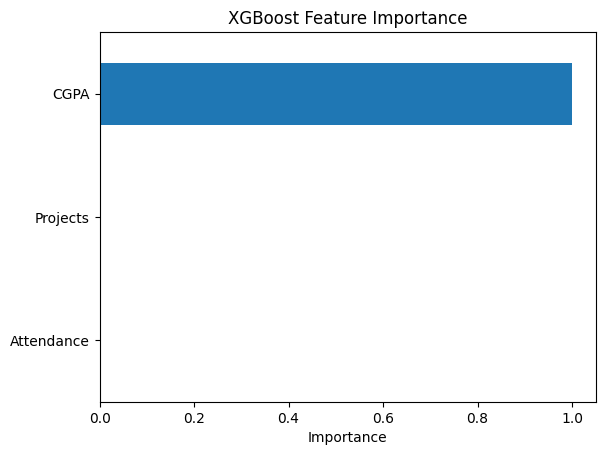

In [11]:
import matplotlib.pyplot as plt

importance.sort_values().plot(
    kind="barh",
    title="XGBoost Feature Importance"
)

plt.xlabel("Importance")
plt.show()

In [12]:
predictions = model.predict(X)

rmse = np.sqrt(
    mean_squared_error(y, predictions)
)

print("RMSE:", rmse)

RMSE: 0.6474093985083934


In [13]:
print(model.get_params())

{'objective': 'reg:squarederror', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': None, 'device': 'cpu', 'early_stopping_rounds': None, 'enable_categorical': True, 'eval_metric': None, 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.3, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 2, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 3, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': 0, 'reg_lambda': 0, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': None, 'tree_method': 'hist', 'validate_parameters': None, 'verbosity': None}


In [14]:
print("Learning Rate :", model.learning_rate)
print("Max Depth     :", model.max_depth)
print("Trees         :", model.n_estimators)
print("Lambda        :", model.reg_lambda)
print("Alpha         :", model.reg_alpha)

Learning Rate : 0.3
Max Depth     : 2
Trees         : 3
Lambda        : 0
Alpha         : 0
